# 04 - Join latent coordinates with metadata and inspect latent structure

This notebook prepares the learned latent representation for downstream analysis.

It performs six tasks:

1. Loads latent coordinates generated by the trained VAE
2. Loads aligned sample metadata from preprocessing
3. Verifies strict row-wise alignment between latent coordinates and metadata
4. Constructs a unified working dataset for analysis
5. Standardizes comparison labels for downstream notebooks
6. Produces initial static and interactive views of latent-space organization

This notebook is diagnostic rather than interpretive. Its purpose is to confirm that the latent representation is correctly aligned with biological labels and suitable for subsequent analyses of within-class complexity and between-class geometry.

In [79]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)


In [80]:
NOTEBOOK_DIR = Path.cwd()
LATENT_PROJECT_DIR = NOTEBOOK_DIR.parent
INPUT_DIR = LATENT_PROJECT_DIR / "data" / "inputs"
PROCESSED_DIR = LATENT_PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = LATENT_PROJECT_DIR / "output"
LATENT_PLOTS_DIR = OUTPUT_DIR / "plots" / "latent"

LATENT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

latent_path = PROCESSED_DIR / "latent.npy"
metadata_path = INPUT_DIR / "hu35ksuba_metadata.csv"

print("Notebook directory      :", NOTEBOOK_DIR)
print("Latent project directory:", LATENT_PROJECT_DIR)
print("Input data directory:", INPUT_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Latent plots directory  :", LATENT_PLOTS_DIR)
print("Latent file exists?     :", latent_path.exists(), latent_path)
print("Metadata file exists?   :", metadata_path.exists(), metadata_path)


Notebook directory      : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\projects\cancer-latent-space\notebooks
Latent project directory: C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\projects\cancer-latent-space
Input data directory: C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\projects\cancer-latent-space\data\inputs
Processed data directory: C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\projects\cancer-latent-space\data\processed
Latent plots directory  : C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\projects\cancer-latent-space\output\plots\latent
Latent file exists?     : True C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\projects\cancer-latent-space\data\processed\latent.npy
Metadata file exists?   : True C:\Users\drziy\OneDri

In [81]:
latent = np.load(latent_path)
metadata = pd.read_csv(metadata_path, index_col=0)

required_cols = [
    "sample_id",
    "geo_accession",
    "title",
    "platform_id",
    "disease_clean",
    "tissue_clean",
    "condition",
    "tissue_label",
]
missing = [c for c in required_cols if c not in metadata.columns]
assert not missing, f"Missing required metadata columns: {missing}"

latent_df = pd.DataFrame(latent, index=metadata.index)
latent_df.columns = [f"z{i+1}" for i in range(latent_df.shape[1])]

df = latent_df.join(metadata)

print("latent shape   :", latent.shape)
print("metadata shape :", metadata.shape)
print("joined shape   :", df.shape)
display(df.head())


latent shape   : (278, 10)
metadata shape : (278, 8)
joined shape   : (278, 18)


,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10,sample_id,geo_accession,title,platform_id,disease_clean,tissue_clean,condition,tissue_label
GSM1686773_CL2000062805AA.CEL,-0.891098,5.696705,-4.469275,7.692773,8.939398,0.992899,-1.079474,13.861112,-3.514981,4.776511,GSM1686773_CL2000062805AA.CEL,GSM1686773,golub-00236: CL2000062805AA,GPL98,prostate adenocarcinoma,Prostate,cancer,prostate_prostate.adenocarcinoma
GSM1686774_CL2000062807AA.CEL,7.145813,3.601434,2.103221,6.663136,4.724164,-5.885802,-0.047318,15.595482,-6.074564,2.251225,GSM1686774_CL2000062807AA.CEL,GSM1686774,golub-00236: CL2000062807AA,GPL98,prostate adenocarcinoma,Prostate,cancer,prostate_prostate.adenocarcinoma
GSM1686775_CL2000062808AA.CEL,1.750058,5.659782,-0.274540,9.270736,7.250854,0.176477,-0.933469,14.510089,-3.529614,5.140491,GSM1686775_CL2000062808AA.CEL,GSM1686775,golub-00236: CL2000062808AA,GPL98,normal,Prostate,normal,prostate
GSM1686789_CL2000071829AA.CEL,11.663876,6.399312,-11.456659,12.533592,10.969925,3.032189,-8.057707,-2.554736,1.057489,9.112515,GSM1686789_CL2000071829AA.CEL,GSM1686789,golub-00236: CL2000071829AA,GPL98,normal,Pancreas,normal,pancreas
GSM1686790_CL2000071830AA.CEL,3.235563,7.657183,-14.741581,5.628472,31.265846,2.108356,-3.039689,-18.400770,22.838043,13.950647,GSM1686790_CL2000071830AA.CEL,GSM1686790,golub-00236: CL2000071830AA,GPL98,normal,Pancreas,normal,pancreas


In [82]:
same_order = latent_df.index.equals(metadata.index)
same_set = set(latent_df.index) == set(metadata.index)

print("Same sample IDs in same order?", same_order)
print("Same sample ID sets?         ", same_set)

assert same_order, "Latent rows and metadata rows are not aligned."
assert metadata["sample_id"].astype(str).equals(metadata.index.to_series().astype(str)), \
    "sample_id column does not match metadata index."

print("Alignment checks passed.")


Same sample IDs in same order? True
Same sample ID sets?          True
Alignment checks passed.


In [83]:
print("Metadata summary")
print("Number of samples        :", df.shape[0])
print("Number of disease labels :", df["disease_clean"].nunique())
print("Number of tissue labels  :", df["tissue_clean"].nunique())

print("\nCondition counts:")
display(df["condition"].value_counts(dropna=False))

Metadata summary
Number of samples        : 278
Number of disease labels : 19
Number of tissue labels  : 15

Condition counts:


condition
cancer    188
normal     90
Name: count, dtype: int64

In [84]:
# Standardized analysis columns
df["tissue"] = df["tissue_clean"]
df["disease"] = df["disease_clean"]
df["state"] = df["condition"]

# Full comparison key (cancer only)
df["comparison"] = None
mask = df["state"] == "cancer"
df.loc[mask, "comparison"] = (
    df.loc[mask, "tissue"] + "/" + df.loc[mask, "disease"]
)

# R-aligned project comparison labels
comparison_map = {
    ("Bladder", "bladder transitional cell carcinoma"): "BLAD/TCC",
    ("Breast", "breast adenocarcinoma"): "BR/BRAD",
    ("Colon", "colorectal adenocarcinoma"): "COL/COADREAD",
    ("Kidney", "renal cell carcinoma"): "KID/RCC",
    ("Lung", "lung adenocarcinoma"): "LU/LUAD",
    ("Ovary", "ovarian adenocarcinoma"): "OV/OVAD",
    ("Pancreas", "pancreatic adenocarcinoma"): "PA/PAAD",
    ("Prostate", "prostate adenocarcinoma"): "PR/PRAD",
    ("Uterus", "uterine adenocarcinoma"): "UT/EAC",

    ("Brain", "glioblastoma"): "Brain/GBM",
    ("Brain", "medulloblastoma"): "Brain/MB",

    ("Lymphoid Tissue", "Follicular lymphoma"): "GC/FL",
    ("Lymphoid Tissue", "large B-cell lymphoma"): "GC/LBCL",

    ("Blood", "acute myeloid leukemia"): "PB/AML",
    ("Bone Marrow", "B-cell ALL"): "PB/B-ALL",
    ("Bone Marrow", "T-cell ALL"): "PB/T-ALL",
}

df["short_label"] = None
df.loc[mask, "short_label"] = [
    comparison_map.get((t, d))
    for t, d in zip(df.loc[mask, "tissue"], df.loc[mask, "disease"])
]

# Plot labels: cancer-only visual abbreviations
plot_label_map = {
    "BLAD/TCC": "TCC",
    "BR/BRAD": "BRAD",
    "COL/COADREAD": "COADREAD",
    "KID/RCC": "RCC",
    "LU/LUAD": "LUAD",
    "OV/OVAD": "OVAD",
    "PA/PAAD": "PAAD",
    "PR/PRAD": "PRAD",
    "UT/EAC": "EAC",
    "Brain/GBM": "GBM",
    "Brain/MB": "MB",
    "GC/FL": "FL",
    "GC/LBCL": "LBCL",
    "PB/AML": "AML",
    "PB/B-ALL": "B-ALL",
    "PB/T-ALL": "T-ALL",
}

df["plot_label"] = None
df.loc[mask, "plot_label"] = df.loc[mask, "short_label"].map(plot_label_map)

# Validate mapping
missing_project = df[(df["state"] == "cancer") & (df["short_label"].isna())]
if not missing_project.empty:
    print("Unmapped cancer labels detected (project labels):")
    display(missing_project[["tissue", "disease"]].drop_duplicates())
else:
    print("All cancer labels mapped to project comparison labels.")

missing_plot = df[(df["state"] == "cancer") & (df["plot_label"].isna())]
if not missing_plot.empty:
    print("Unmapped cancer labels detected (plot labels):")
    display(missing_plot[["short_label", "tissue", "disease"]].drop_duplicates())
else:
    print("All project labels mapped to plot labels.")

# Build working table
latent_working = df[
    [
        "geo_accession",
        "title",
        "platform_id",
        "tissue",
        "disease",
        "state",
        "comparison",
        "short_label",
        "plot_label",
        "tissue_label"
    ] +
    [col for col in df.columns if col.startswith("z")]
].copy()

print("Working latent-analysis table created.")
display(latent_working.head())

Unmapped cancer labels detected (project labels):


,tissue,disease
GSM1686793_CL2000071834AA.CEL,Skin,melanoma
GSM1687115_SR2000050501AA.CEL,Mesothelium,mesothelioma
GSM1687150_SR2000051901AA.CEL,Bone Marrow,acute myeloid leukemia


Unmapped cancer labels detected (plot labels):


,short_label,tissue,disease
GSM1686793_CL2000071834AA.CEL,None,Skin,melanoma
GSM1687115_SR2000050501AA.CEL,None,Mesothelium,mesothelioma
GSM1687150_SR2000051901AA.CEL,None,Bone Marrow,acute myeloid leukemia


Working latent-analysis table created.


,geo_accession,title,platform_id,tissue,disease,state,comparison,short_label,plot_label,tissue_label,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10
GSM1686773_CL2000062805AA.CEL,GSM1686773,golub-00236: CL2000062805AA,GPL98,Prostate,prostate adenocarcinoma,cancer,Prostate/prostate adenocarcinoma,PR/PRAD,PRAD,prostate_prostate.adenocarcinoma,-0.891098,5.696705,-4.469275,7.692773,8.939398,0.992899,-1.079474,13.861112,-3.514981,4.776511
GSM1686774_CL2000062807AA.CEL,GSM1686774,golub-00236: CL2000062807AA,GPL98,Prostate,prostate adenocarcinoma,cancer,Prostate/prostate adenocarcinoma,PR/PRAD,PRAD,prostate_prostate.adenocarcinoma,7.145813,3.601434,2.103221,6.663136,4.724164,-5.885802,-0.047318,15.595482,-6.074564,2.251225
GSM1686775_CL2000062808AA.CEL,GSM1686775,golub-00236: CL2000062808AA,GPL98,Prostate,normal,normal,None,None,None,prostate,1.750058,5.659782,-0.274540,9.270736,7.250854,0.176477,-0.933469,14.510089,-3.529614,5.140491
GSM1686789_CL2000071829AA.CEL,GSM1686789,golub-00236: CL2000071829AA,GPL98,Pancreas,normal,normal,None,None,None,pancreas,11.663876,6.399312,-11.456659,12.533592,10.969925,3.032189,-8.057707,-2.554736,1.057489,9.112515
GSM1686790_CL2000071830AA.CEL,GSM1686790,golub-00236: CL2000071830AA,GPL98,Pancreas,normal,normal,None,None,None,pancreas,3.235563,7.657183,-14.741581,5.628472,31.265846,2.108356,-3.039689,-18.400770,22.838043,13.950647


In [85]:
df_cancer = df[df["state"] == "cancer"].copy()

print("Cancer-only samples:", df_cancer.shape[0])
print("Unique cancer types (full labels):", df_cancer["disease"].nunique())
print("Unique project labels:", df_cancer["short_label"].nunique())
print("Unique plot labels:", df_cancer["plot_label"].nunique())

Cancer-only samples: 188
Unique cancer types (full labels): 18
Unique project labels: 15
Unique plot labels: 15


In [86]:
unmapped = df_cancer[df_cancer["short_label"].isna()]

if not unmapped.empty:
    print("Warning: unmapped cancer samples detected")
    display(unmapped[["tissue", "disease"]].drop_duplicates())

,tissue,disease
GSM1686793_CL2000071834AA.CEL,Skin,melanoma
GSM1687115_SR2000050501AA.CEL,Mesothelium,mesothelioma
GSM1687150_SR2000051901AA.CEL,Bone Marrow,acute myeloid leukemia


In [87]:
df_cancer = df[df["state"] == "cancer"].copy()

print("Cancer-only samples:", df_cancer.shape[0])

Cancer-only samples: 188


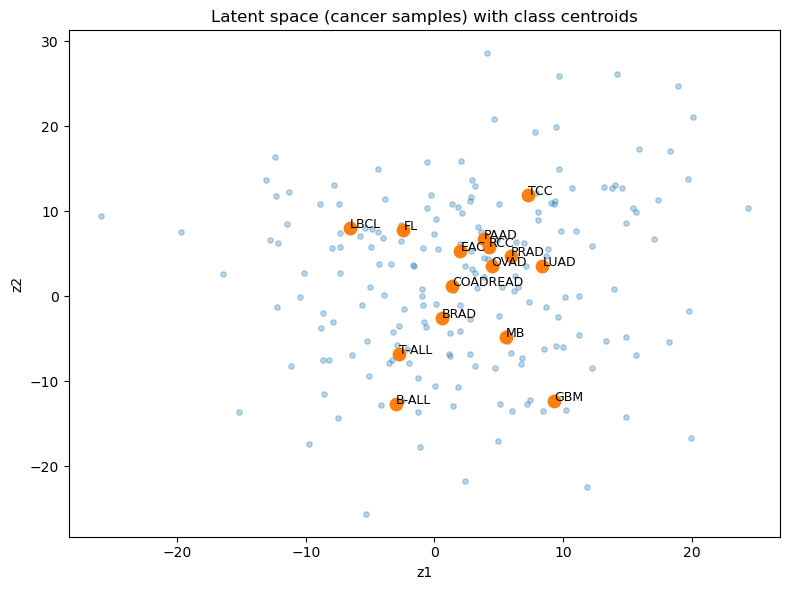

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Background points
plt.scatter(
    df_cancer["z1"],
    df_cancer["z2"],
    s=15,
    alpha=0.3
)

# Centroids by plot label
centroids = (
    df_cancer
    .dropna(subset=["plot_label"])
    .groupby("plot_label")[["z1", "z2"]]
    .mean()
)

# Plot centroids
plt.scatter(
    centroids["z1"],
    centroids["z2"],
    s=80
)

# Label centroids
for label, row in centroids.iterrows():
    plt.text(
        row["z1"],
        row["z2"],
        label,
        fontsize=9
    )

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent space (cancer samples) with class centroids")
plt.tight_layout()

plt.savefig(
    LATENT_PLOTS_DIR / "latent_space_centroids.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [89]:
import plotly.express as px
import plotly.graph_objects as go

plot_df = df_cancer.dropna(subset=["plot_label"]).copy()

# Base scatter
fig = px.scatter(
    plot_df,
    x="z1",
    y="z2",
    color="plot_label",
    hover_data=[
        "short_label",
        "tissue",
        "disease",
        "comparison",
        "geo_accession",
        "title"
    ],
    title="Latent space with class centroids"
)

fig.update_traces(marker=dict(size=6, opacity=0.7))

# Compute centroids
centroids = (
    plot_df
    .groupby("plot_label")[["z1", "z2"]]
    .mean()
    .reset_index()
)

# Add centroid layer
fig.add_trace(
    go.Scatter(
        x=centroids["z1"],
        y=centroids["z2"],
        mode="markers+text",
        text=centroids["plot_label"],
        textposition="top center",
        marker=dict(
            size=8,
            symbol="x",
            line=dict(width=2)
        ),
        name="Centroids",
        showlegend=False  # avoids clutter
    )
)

# Layout fix (legend inside)
fig.update_layout(
    height=650,
    legend=dict(
        x=0.99,
        y=0.99,
        xanchor="right",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.7)"
    )
)

fig.show()

In [90]:
fig.write_html(LATENT_PLOTS_DIR / "latent_space_interactive.html")

In [91]:
# Construct standardized analysis columns
df["tissue"] = df["tissue_clean"]
df["disease"] = df["disease_clean"]
df["state"] = df["condition"]

# Define comparison key (cancer only)
df["comparison"] = None
mask = df["state"] == "cancer"
df.loc[mask, "comparison"] = (
    df.loc[mask, "tissue"] + "/" + df.loc[mask, "disease"]
)

# Build working table
latent_working = df[
    [
        "geo_accession",
        "title",
        "platform_id",
        "tissue",
        "disease",
        "state",
        "comparison",
        "tissue_label"
    ] +
    [col for col in df.columns if col.startswith("z")]
].copy()

print("Working latent-analysis table created.")

Working latent-analysis table created.
